# Customer Churn Prediction
## Preprocessing Technique 01 — Handling Missing Values and Duplicate Values
**Member: Lathurshan-IT25103438**

This notebook follows the same overall flow as the uploaded reference notebook, but it is adapted to the **Churn_Modelling.csv** dataset.

### Main tasks
- Load and inspect the dataset
- Identify missing values
- Visualize missing values
- Identify duplicate rows
- Visualize unique vs duplicate rows
- Handle missing values
- Remove duplicate rows
- Compare the dataset before and after preprocessing
- Save the cleaned dataset for the next preprocessing notebook


In [1]:
# Basic libraries
import numpy as np
import pandas as pd


In [2]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")


## 1. Load the Dataset

For Google Colab, upload `Churn_Modelling.csv` to the `/content/` folder.

The fallback path allows this notebook to run locally if the CSV file is in the same folder as the notebook.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [4]:
from pathlib import Path

colab_path = Path("/content/Churn_Modelling.csv")
local_path = Path("Churn_Modelling.csv")

if colab_path.exists():
    file_path = colab_path
elif local_path.exists():
    file_path = local_path
else:
    raise FileNotFoundError(
        "Churn_Modelling.csv was not found. Upload it to Colab or place it in the same folder as this notebook."
    )

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Initial Dataset Inspection


In [5]:
print("Dataset Information")
print("-" * 60)
df.info()

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nMissing values in each column:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\nStatistical Summary:")
display(df.describe(include="all").T)


Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Number of du

,Missing Values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


## 3. Missing Value Analysis — Before Cleaning

A heatmap is used to visually inspect missing values across the dataset.

- A visible colored gap would indicate a missing value.
- If the heatmap has no missing-value pattern, the dataset has no null values.


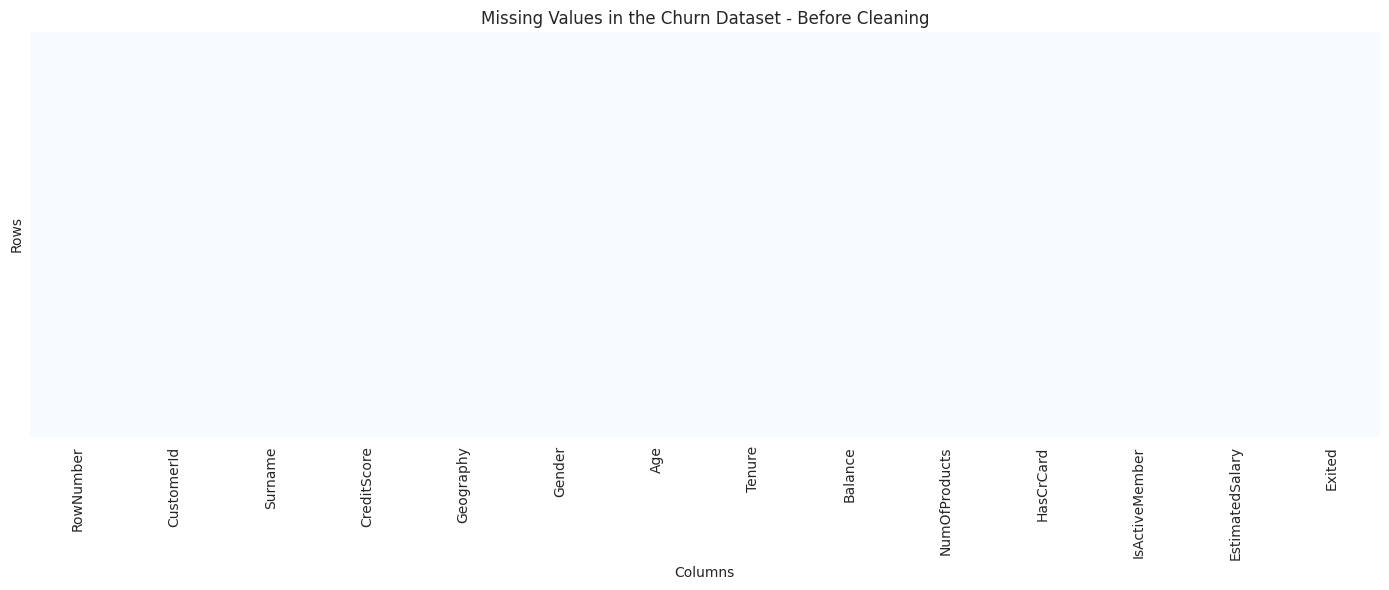

In [6]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="Blues",
    yticklabels=False
)

plt.title("Missing Values in the Churn Dataset - Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


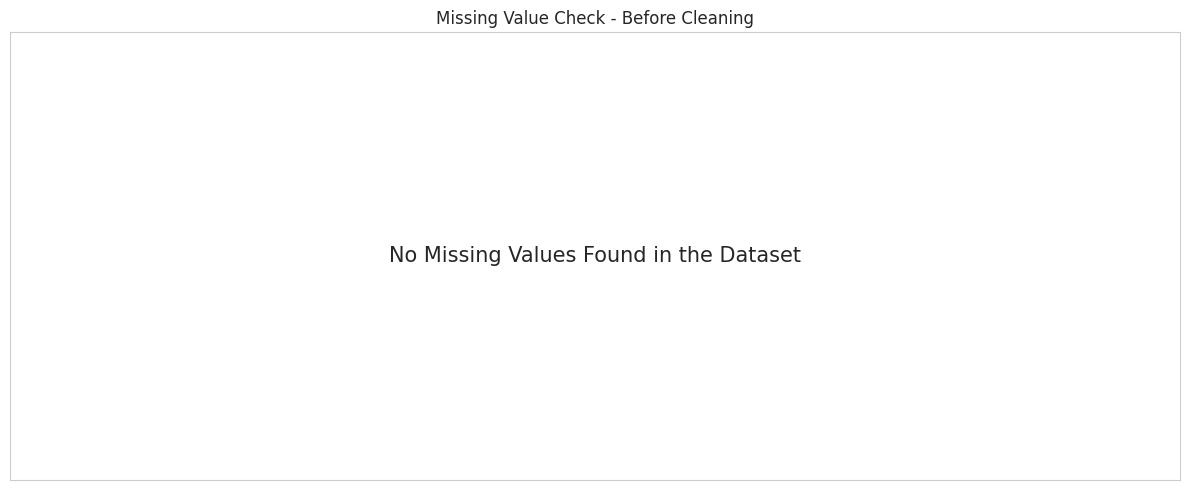

In [7]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))

if len(missing_count) > 0:
    sns.barplot(x=missing_count.index, y=missing_count.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Columns")
    plt.title("Missing Values by Column - Before Cleaning")
else:
    plt.text(
        0.5, 0.5,
        "No Missing Values Found in the Dataset",
        ha="center", va="center",
        fontsize=15
    )
    plt.xticks([])
    plt.yticks([])
    plt.title("Missing Value Check - Before Cleaning")

plt.tight_layout()
plt.show()


## 4. Duplicate Value Analysis — Before Cleaning

The following chart compares the number of unique rows and fully duplicated rows.


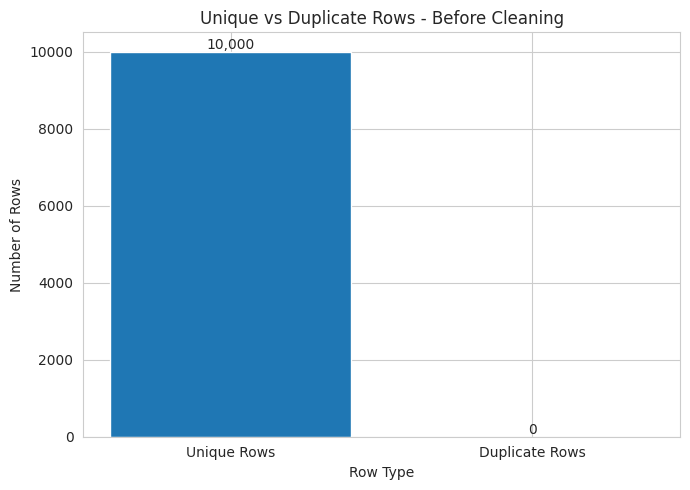

Unique rows: 10000
Duplicate rows: 0


In [8]:
duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

plt.figure(figsize=(7, 5))

plt.bar(
    ["Unique Rows", "Duplicate Rows"],
    [unique_count, duplicate_count]
)

plt.title("Unique vs Duplicate Rows - Before Cleaning")
plt.xlabel("Row Type")
plt.ylabel("Number of Rows")

for i, value in enumerate([unique_count, duplicate_count]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("Unique rows:", unique_count)
print("Duplicate rows:", duplicate_count)


## 5. EDA Before Cleaning

To understand the data before preprocessing, we inspect the target distribution and selected numerical feature distributions.


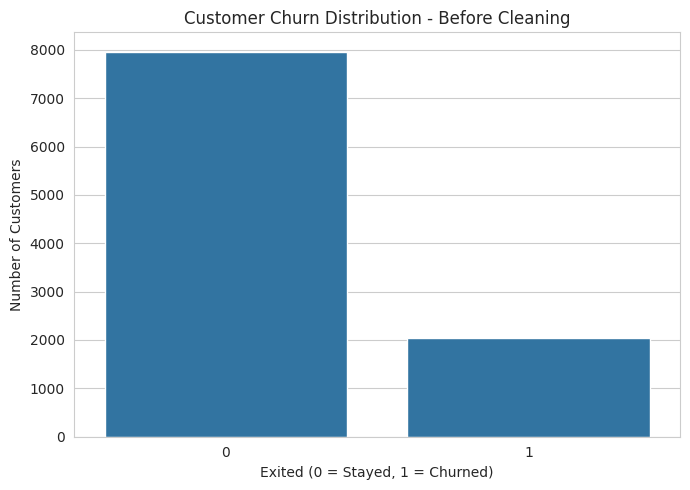

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution - Before Cleaning")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


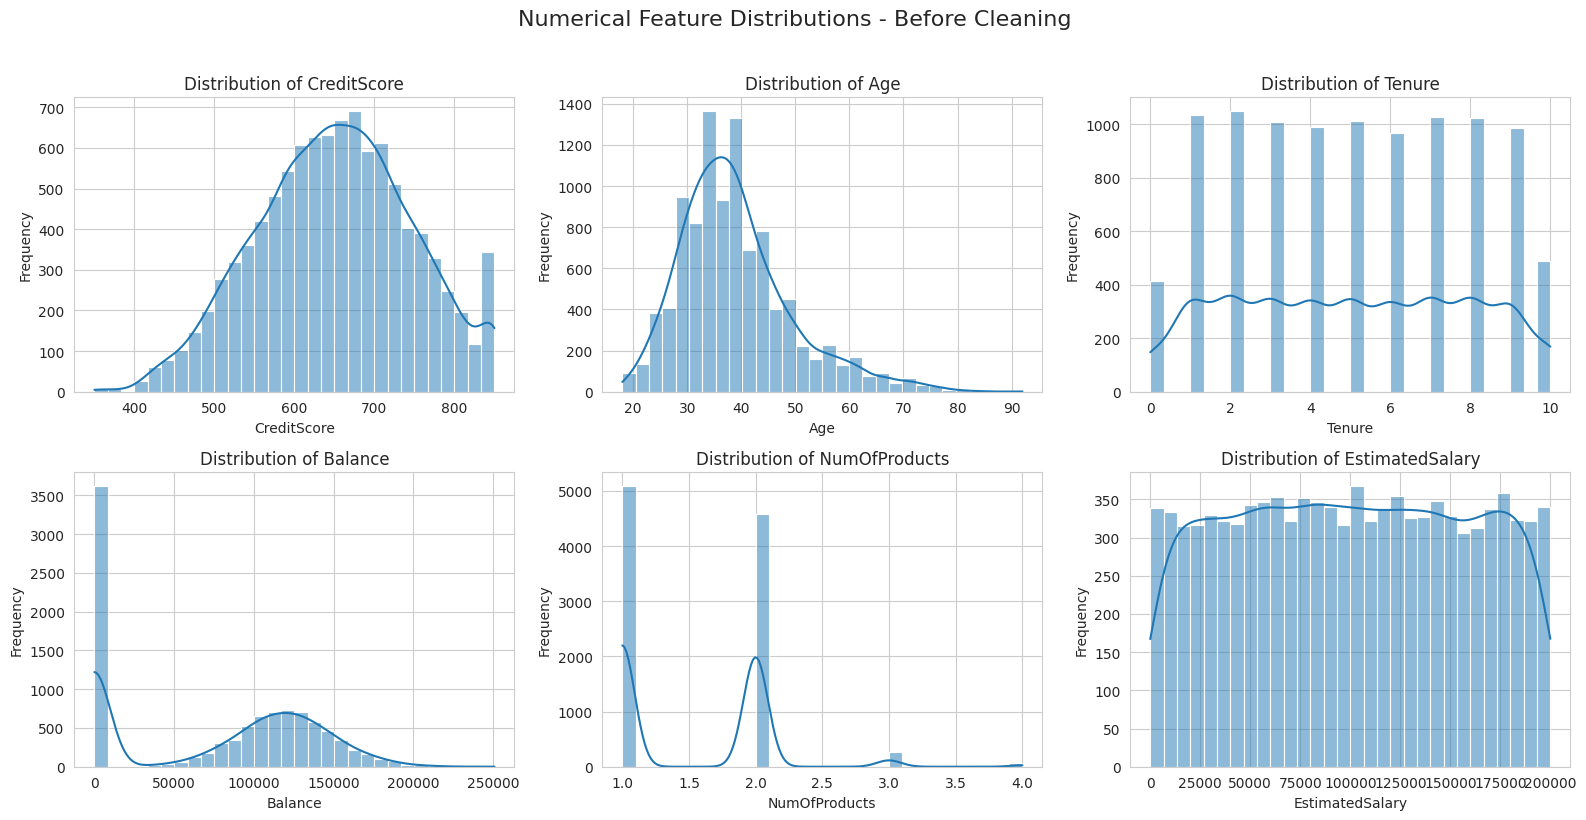

In [10]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Numerical Feature Distributions - Before Cleaning", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## 6. Handle Missing Values

The cleaning strategy is:

- **Numerical columns:** fill missing values using the **median**
- **Categorical columns:** fill missing values using the **mode**

The current churn dataset is expected to contain no missing values, but this code is written safely so that it will also work if missing values are introduced later.


In [11]:
df_cleaned = df.copy()

numeric_cols = df_cleaned.select_dtypes(include=np.number).columns
categorical_cols = df_cleaned.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Total missing values before handling:", df.isnull().sum().sum())
print("Total missing values after handling :", df_cleaned.isnull().sum().sum())


Total missing values before handling: 0
Total missing values after handling : 0


## 7. Remove Duplicate Rows

`drop_duplicates()` removes only fully duplicated rows and keeps the first occurrence.


In [12]:
rows_before = len(df_cleaned)

df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

rows_after = len(df_cleaned)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal :", rows_after)
print("Duplicates removed           :", rows_before - rows_after)


Rows before duplicate removal: 10000
Rows after duplicate removal : 10000
Duplicates removed           : 0


## 8. Validation After Cleaning

After preprocessing, we verify that:
- no missing values remain
- no duplicate rows remain


In [13]:
print("Missing values after cleaning:")
display(df_cleaned.isnull().sum().to_frame(name="Missing Values"))

print("\nDuplicate rows after cleaning:", df_cleaned.duplicated().sum())
print("Cleaned dataset shape:", df_cleaned.shape)


Missing values after cleaning:


,Missing Values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Duplicate rows after cleaning: 0
Cleaned dataset shape: (10000, 14)


## 9. EDA Visualization — After Cleaning


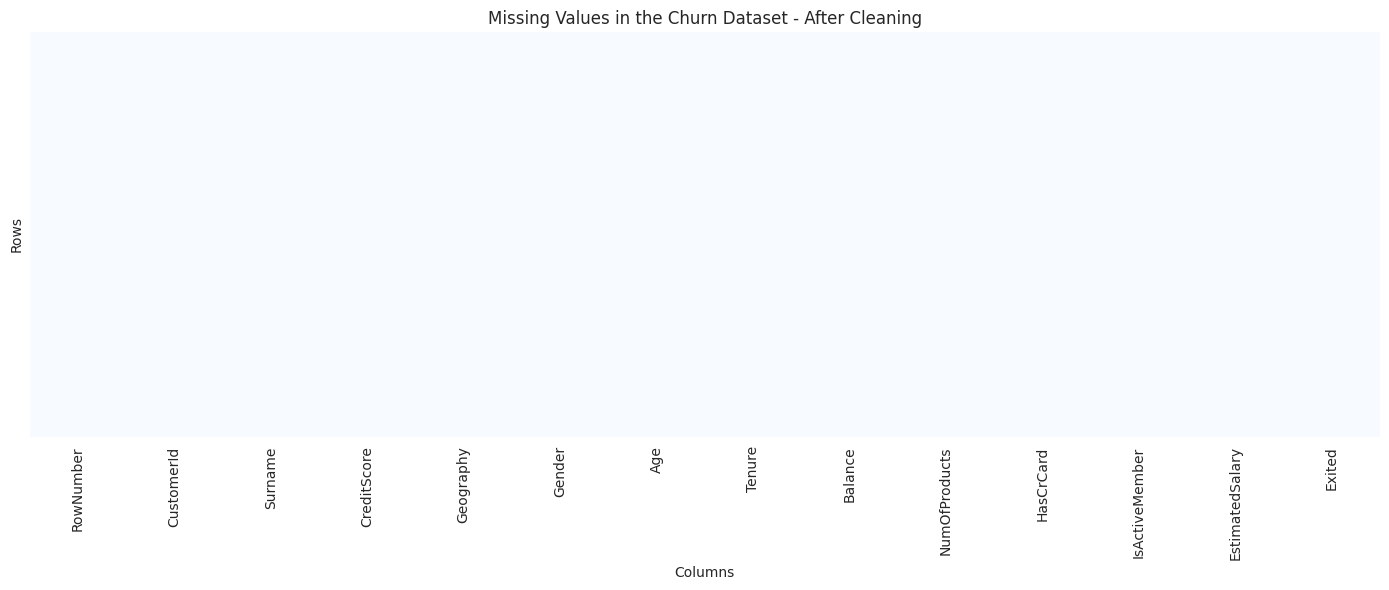

In [14]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    df_cleaned.isnull(),
    cbar=False,
    cmap="Blues",
    yticklabels=False
)

plt.title("Missing Values in the Churn Dataset - After Cleaning")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


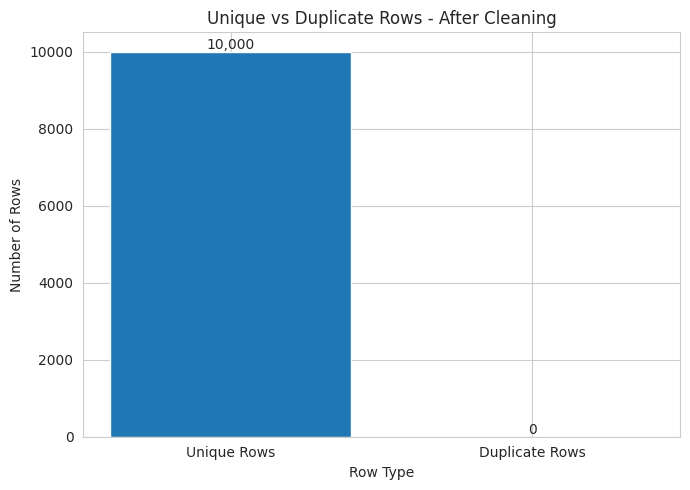

In [15]:
duplicate_after = df_cleaned.duplicated().sum()
unique_after = len(df_cleaned) - duplicate_after

plt.figure(figsize=(7, 5))

plt.bar(
    ["Unique Rows", "Duplicate Rows"],
    [unique_after, duplicate_after]
)

plt.title("Unique vs Duplicate Rows - After Cleaning")
plt.xlabel("Row Type")
plt.ylabel("Number of Rows")

for i, value in enumerate([unique_after, duplicate_after]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


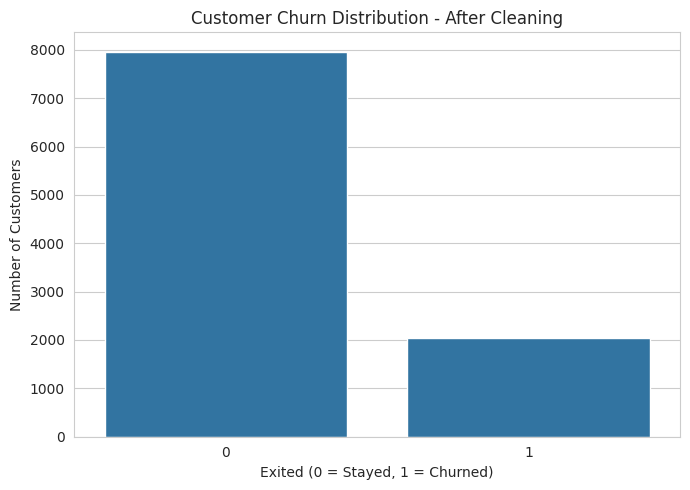

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_cleaned, x="Exited")

plt.title("Customer Churn Distribution - After Cleaning")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


## 10. Before vs After Preprocessing Summary


In [17]:
summary = pd.DataFrame({
    "Measure": [
        "Number of Rows",
        "Number of Columns",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        df_cleaned.shape[0],
        df_cleaned.shape[1],
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum()
    ]
})

display(summary)


,Measure,Before Cleaning,After Cleaning
0,Number of Rows,10000,10000
1,Number of Columns,14,14
2,Total Missing Values,0,0
3,Duplicate Rows,0,0


## 11. Save the Cleaned Dataset

This output file can be used as the input for the next preprocessing notebook in the group pipeline.


In [18]:
output_file = "01_cleaned_missing_duplicates.csv"

df_cleaned.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")
print("Final dataset shape:", df_cleaned.shape)


Cleaned dataset saved as: 01_cleaned_missing_duplicates.csv
Final dataset shape: (10000, 14)


In [19]:
from google.colab import files

files.download("01_cleaned_missing_duplicates.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

For this churn dataset:

- Missing values were checked and handled using median/mode logic where required.
- Duplicate rows were checked and removed where required.
- EDA visualizations were produced before and after preprocessing.
- The cleaned dataset is ready to be passed to the next preprocessing stage: **Encoding Categorical Variables**.

Because the original `Churn_Modelling.csv` currently contains no missing values and no fully duplicated rows, the number of records remains unchanged after this preprocessing step.
